Output()

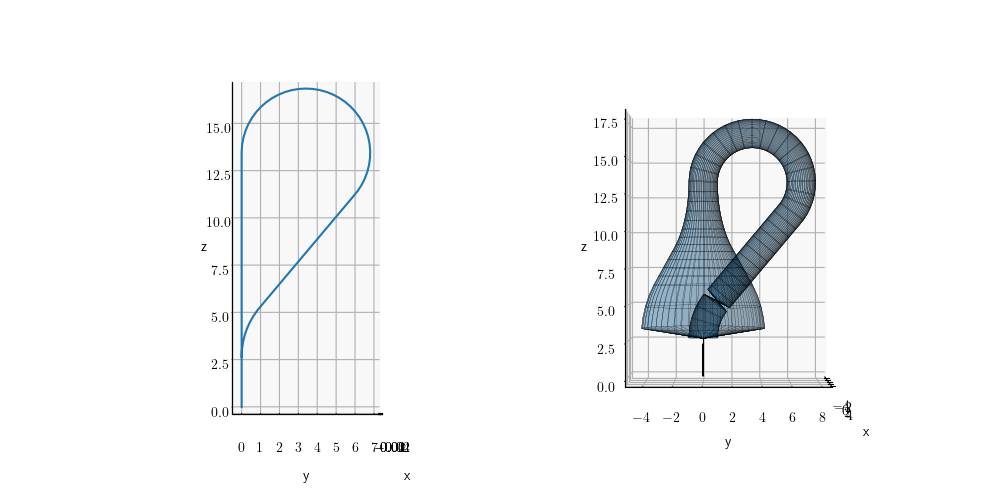

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from ipywidgets import Layout

import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

plt.rcParams['text.usetex'] = True

p = widgets.FloatText(value=1,min=0,max=5,step=.1,description='p')
a = widgets.FloatText(value=3.4,min=0,max=5,step=.1,description='a')
b = widgets.FloatText(value=4,min=0,max=5,step=.1,description='b')
theta = widgets.FloatText(value=.7,min=0,max=np.pi/2,step=.01,description='θ')
phi = widgets.FloatText(value=.45,min=0,max=np.pi/2,step=.01,description='ϕ')
w = widgets.FloatText(value=8.6,min=0,max=20,step=.1,description='w')

def f(p,a,b,theta,phi,w):
    plt.clf()
    plt.close()
    
    h = (a+b+(a-b)*np.cos(theta))/np.sin(theta)
    d = np.sqrt((w/2)*((w/2)-p)/2)
    c = (h*np.sin(phi)+p*np.cos(phi)-(w/2))/(1-np.cos(phi))
    
    P = np.array([0,a*(1+np.cos(theta)),d+h-a*np.sin(theta)])
    Q = np.array([0,b*(1-np.cos(theta)),d+b*np.sin(theta)])
    PQ = Q-P
    magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
    PQhat = PQ/magPQ
    
    X = np.array([0,(w/2)*np.cos(phi),d+(w/2)*np.sin(phi)])
    Y = np.array([0,p+c-c*np.cos(phi),h-c*np.sin(phi)])
    
    #Arc lengths and step sizes
    AL = np.array([0, 2*d, (w/2)*np.sin(phi), h-c*np.sin(phi)-(w/2)*np.sin(phi), c*np.sin(phi), a*(np.pi+theta), magPQ, b*theta])
    TotalAL = np.sum(AL)
    Proportions = AL/TotalAL
    TotalSteps = 1000
    Steps = np.round(TotalSteps*Proportions)

    # set up a figure twice as wide as it is tall
    fig, axs = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(10,5))

    t = np.array([
        0,
        d, 
        (w/2)*np.sin(phi)+d, 
        h-c*np.sin(phi)+d, 
        h+d, 
        h+d+a*(np.pi+theta), 
        h+d+a*(np.pi+theta)+magPQ, 
        h+d+a*(np.pi+theta)+magPQ+b*theta
    ])

    u = np.linspace(0, h+d+a*(np.pi+theta)+magPQ+b*theta, 100)
    gamma = np.zeros((3,100))
    T = np.zeros((3,100))
    N = np.zeros((3,100))
    B = np.zeros((3,100))
    r = np.zeros(100)
    rdot = np.zeros(100)

    for j in range(100):
        if u[j] < t[4]:
            #Diretrix
            gamma[:,j] = (0,0,u[j])
            #ON frame
            T[:,j] = (0,0,1)
            N[:,j] = (0,1,0)
            B[:,j] = (1,0,0)
            #Radius function
            if t[1] < u[j] <= t[2]:
                r[j] = np.sqrt((w/2)**2-(u[j]-d)**2)
                rdot[j] = -(u[j]-d)/np.sqrt((w/2)**2-(u[j]-d)**2)
            elif t[2] < u[j] <= t[3]:
                r[j] = (w/2)/np.cos(phi)-(u[j]-d)*np.tan(phi)
                rdot[j] = -np.tan(phi)
            elif t[3] < u[j] <= t[4]:
                r[j] = p+c-np.sqrt(c**2-(u[j]-t[4])**2)
                rdot[j] = (u[j]-t[4])/np.sqrt(c**2-(u[j]-t[4])**2)
        else:
            #Handle
            #Radius function
            r[j] = p
            rdot[j] = 0            
            if u[j] <= t[5]:
                #Directrix
                gamma[:,j] = (0, a*(1+np.cos(np.pi-(u[j]-t[4])/a)), d+h+a*np.sin(np.pi-(u[j]-t[4])/a))
                #ON frame
                T[:,j] = (0,np.sin(np.pi-(u[j]-t[4])/a),-np.cos(np.pi-(u[j]-t[4])/a))
                N[:,j] = (0,-np.cos(np.pi-(u[j]-t[4])/a),-np.sin(np.pi-(u[j]-t[4])/a))
                B[:,j] = (1,0,0)
            elif t[5] < u[j] <= t[6]:
                #Directrix
                gamma[:,j] = ((u[j]-t[5])/magPQ)*Q + (1-(u[j]-t[5])/magPQ)*P
                #ON frame
                T[:,j] = (0,PQhat[1],PQhat[2])
                N[:,j] = (0,PQhat[2],-PQhat[1])
                B[:,j] = (1,0,0)
            elif t[6] < u[j] <= t[7]:
                #Directrix
                gamma[:,j] = (0, b+b*np.cos(np.pi-theta+(u[j]-t[6])/b), d+b*np.sin(np.pi-theta+(u[j]-t[6])/b))
                #ON frame
                T[:,j] = (0,-np.sin(np.pi-theta+(u[j]-t[6])/b),np.cos(np.pi-theta+(u[j]-t[6])/b))
                N[:,j] = (0,-np.cos(np.pi-theta+(u[j]-t[6])/b),-np.sin(np.pi-theta+(u[j]-t[6])/b))
                B[:,j] = (1,0,0)

    #Directrix plot
    x = gamma[0]
    y = gamma[1]
    z = gamma[2]
    
    axs[0].plot(x, y, z)

    print('T = ',T)
    print('N = ',N)

    #Canal surface plot
    v = np.linspace(0,2*np.pi,100)
    u, v = np.meshgrid(u, v)
    
    x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
    y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
    z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 
    
    axs[1].plot_surface(x, y, z, edgecolor = 'black', linewidth = .1, alpha = .25)
    
    #Annotations
    #ax.scatter(P[0],P[1],P[2],color='k')
    #ax.text(P[0],P[1],P[2]-.5*a, "P")
    
    #ax.scatter(Q[0],Q[1],Q[2],color='k')
    #ax.text(Q[0],Q[1],Q[2]-.5*a, "Q")

    for ax in axs:
        # Axis labels
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        
        ax.set_aspect('equal')
        
        ax.view_init(elev=0, azim=0, roll=0)

output =  widgets.interactive_output(f, {'p': p, 'a': a, 'b': b, 'theta': theta, 'phi': phi, 'w': w})

display(output)